In [1]:
pip install pandas mlxtend matplotlib

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 12.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/9.8 MB 13.0 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.8 MB 10.0 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.8 MB 8.2 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.8 MB 6.9 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.8 MB 5.3 MB/s eta 0:00:01
   ----------------------- ---------------- 5.8/9.8 MB 4.5 MB/s eta 0:00:01
   ------------------------ --------------- 6.0/9.8 MB 4.2 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.8 MB 3.8 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.8 MB 3.7 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.8 MB 3.4 MB/s eta 0:00:01
   --------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.5.1 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
streamlit 1.45.1 requires pandas<3,>=1.4.0, but you have pandas 3.0.5 which is incompatible.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules



c:\Users\AB\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
df = pd.read_csv(r"C:\Users\AB\Downloads\archive (21)\Groceries_dataset.csv")

In [5]:
print(df.head())

   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


In [6]:
print(df.shape)

(38765, 3)


In [7]:
print(df.isnull().sum())

Member_number      0
Date               0
itemDescription    0
dtype: int64


In [8]:
df = df.drop_duplicates()

In [9]:
transactions = []

for row in df.values:
    transaction = []

    for item in row:
        if pd.notna(item):
            transaction.append(str(item).strip())

    transactions.append(transaction)

print("\nSample Transactions")
print(transactions[:5])


Sample Transactions
[['1808', '21-07-2015', 'tropical fruit'], ['2552', '05-01-2015', 'whole milk'], ['2300', '19-09-2015', 'pip fruit'], ['1187', '12-12-2015', 'other vegetables'], ['3037', '01-02-2015', 'whole milk']]


In [10]:
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)

print("\nBasket Data")
print(basket.head())



Basket Data
   01-01-2014  01-01-2015  01-02-2014  01-02-2015  01-03-2014  01-03-2015  \
0       False       False       False       False       False       False   
1       False       False       False       False       False       False   
2       False       False       False       False       False       False   
3       False       False       False       False       False       False   
4       False       False       False        True       False       False   

   01-04-2014  01-04-2015  01-05-2014  01-05-2015  ...  turkey  vinegar  \
0       False       False       False       False  ...   False    False   
1       False       False       False       False  ...   False    False   
2       False       False       False       False  ...   False    False   
3       False       False       False       False  ...   False    False   
4       False       False       False       False  ...   False    False   

   waffles  whipped/sour cream  whisky  white bread  white wine  whole mi

In [11]:
frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

print("\nFrequent Itemsets")
print(frequent_itemsets.sort_values(by="support", ascending=False))


Frequent Itemsets
     support                       itemsets
9   0.062174        frozenset({whole milk})
2   0.048071  frozenset({other vegetables})
4   0.043309        frozenset({rolls/buns})
7   0.038231              frozenset({soda})
10  0.033810            frozenset({yogurt})
5   0.027390   frozenset({root vegetables})
8   0.026680    frozenset({tropical fruit})
0   0.023891     frozenset({bottled water})
6   0.023759           frozenset({sausage})
1   0.020918      frozenset({citrus fruit})
3   0.020365            frozenset({pastry})


In [12]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.30
)

print("\nAssociation Rules")
print(rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]])



Association Rules
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [13]:
top_rules = rules.sort_values(by="lift", ascending=False)

print("\nTop 10 Product Recommendations")

print(top_rules.head(10)[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]])


Top 10 Product Recommendations
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [14]:
top_items = frequent_itemsets.sort_values(
    by="support",
    ascending=False
).head(10)

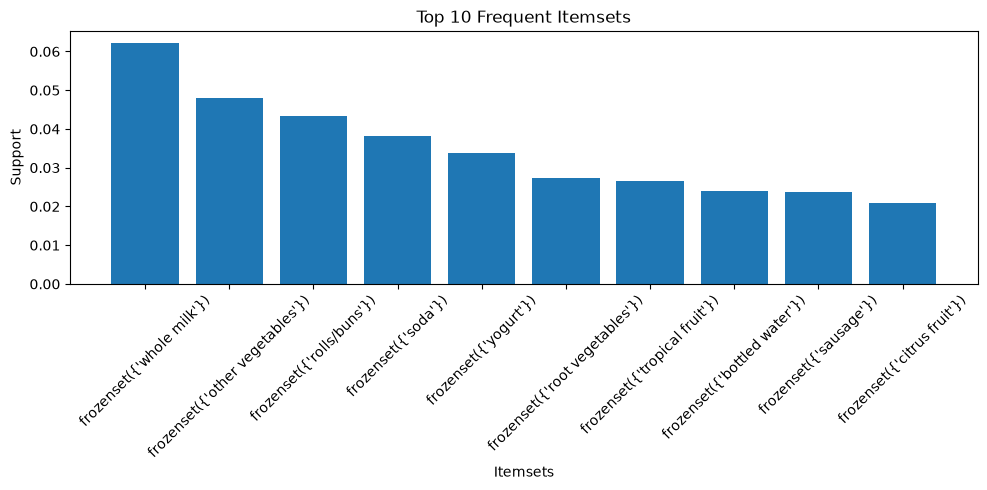

In [16]:
plt.figure(figsize=(10,5))

plt.bar(
    top_items["itemsets"].astype(str),
    top_items["support"]
)

plt.title("Top 10 Frequent Itemsets")
plt.xlabel("Itemsets")
plt.ylabel("Support")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



In [17]:

print("Total Transactions :", len(transactions))
print("Unique Products :", len(basket.columns))
print("Frequent Itemsets :", len(frequent_itemsets))
print("Association Rules :", len(rules))

print("\nTop Product Recommendations")

Total Transactions : 38006
Unique Products : 4793
Frequent Itemsets : 11
Association Rules : 0

Top Product Recommendations
